In [486]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [487]:
# scikit - learn -> Machine Learning Packages
# Linear Regression Model
# Train and Test Package
# Regression metrics
# data scaling

In [488]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
# Train and Test Package
from sklearn.model_selection import train_test_split
# Regression metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# data scaling
from sklearn.preprocessing import StandardScaler


In [489]:
df = pd.read_csv('E:/Courses/DS/Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [490]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

<Axes: >

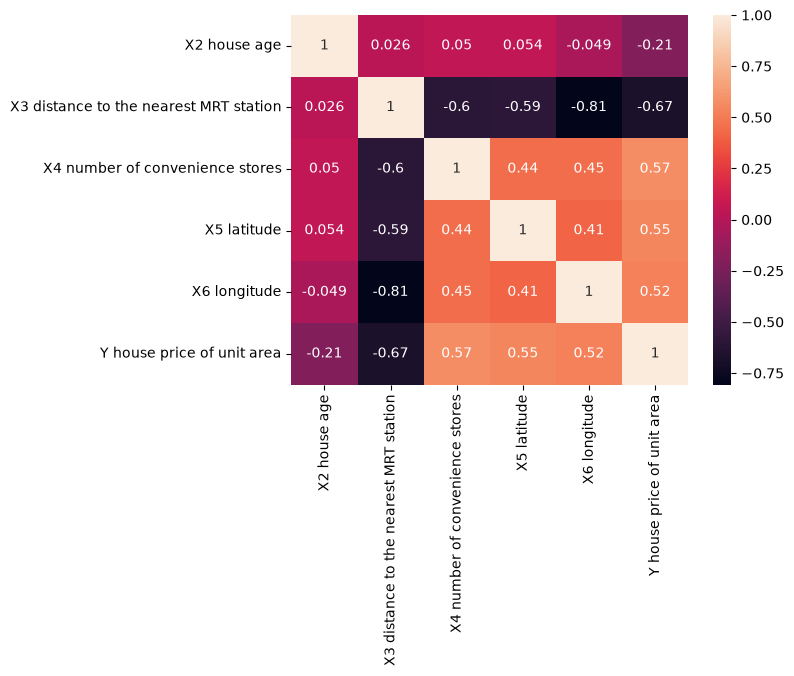

In [491]:
corr_data = df[[
    'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'
]].corr()
corr_data
sns.heatmap(corr_data, annot = True)

In [492]:
duplicate_data = df[df.duplicated()]
duplicate_data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


In [493]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

<Axes: >

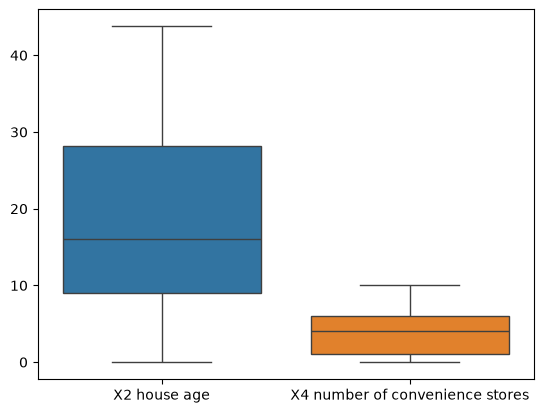

In [494]:
sns.boxplot(df[[
    'X2 house age',
    'X4 number of convenience stores'
]])

In [495]:
filter_df = df[df['X3 distance to the nearest MRT station'] < 2400]

<Axes: >

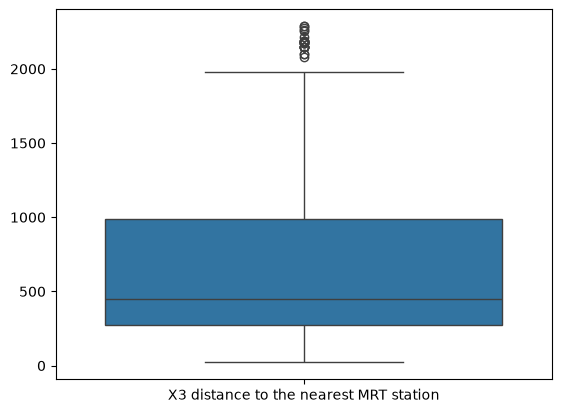

In [496]:
sns.boxplot(filter_df[[
    'X3 distance to the nearest MRT station'
]])

## Feature and Target

In [497]:
feature = [
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',      
]

target = 'Y house price of unit area'

In [498]:
x = filter_df[feature]
y = filter_df[target]

## Tain and Test

In [499]:
'''

x -> feature
y -> target
test_size
random_state -> Shuffle Data -> Seperate 20% of both 
feature and target for testing from 42th index and below

'''

'\n\nx -> feature\ny -> target\ntest_size\nrandom_state -> Shuffle Data -> Seperate 20% of both \nfeature and target for testing from 42th index and below\n\n'

In [500]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state = 42
)

## Feature Scaling

In [501]:
scaler = StandardScaler()

In [502]:
# (Xi - mean)/sd
# fit_transform(feature_training)
x_train_scale = scaler.fit_transform(x_train)
# transform(feature_testing)
x_test_scale = scaler.transform(x_test)

In [503]:
# Define Model
model = LinearRegression()

In [504]:
model.fit(x_train_scale, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-3.79,-7.26, 1.8 , 2.19,-0.62]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.41
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[25.7 ,17.36,15.76,13.31, 8.51]"


In [505]:
beta_0 = model.intercept_ # Intercept
print(f'Intercept: {beta_0}')
beta_1 = model.coef_[4] # Slope / Coefficient
print(f'Slope / Coefficient: {beta_1}')
# B0 + B1*x1 + B2*x2 + ... + B4*x4
# Y=mX + c

Intercept: 40.41061643835757
Slope / Coefficient: -0.624595682311619


In [506]:
y_pred = model.predict(x_test_scale)
y_pred

array([35.90886552, 27.0073308 , 43.1376207 , 26.2720064 , 50.8875376 ,
       49.72441704, 35.90172543, 30.71938797, 37.80714983, 39.64535724,
       39.83808737, 37.91421961, 49.15375154, 31.23388189, 21.64051044,
       37.46759428, 48.62842157, 41.10589339, 25.09577909, 38.74698543,
       36.28963704, 39.45301561, 48.2847466 , 38.56919566, 28.97222326,
       35.87597452, 22.12389564, 22.5160551 , 28.32242499, 54.40814418,
       44.01306507, 49.60574626, 41.18874307, 46.52575608, 41.21519174,
       42.68069193, 41.66902494, 35.53124258, 37.59327375, 27.61377982,
       38.60208666, 21.85077169, 47.14868357, 35.97521897, 50.8546466 ,
       45.73958721, 37.6885322 , 42.48175178, 25.2602341 , 42.84058654,
       37.97625435, 40.2436826 , 36.04819376, 41.34620244, 24.33046512,
       55.34401534, 26.9415488 , 46.86090994, 50.92489974, 49.72441704,
       44.39529352, 49.16331959, 35.87597452, 47.82001327, 49.85373966,
       44.90084404, 52.59760742, 47.78712227, 46.93900666, 54.14

In [507]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [508]:
print(f'Mean Absolute Error: {mae}')
print(f'Mean squared Error: {mse}')
print(f'Root Mean squared Error: {rmse}')
print(f'R2 Score: {r2}')

Mean Absolute Error: 5.943579332578096
Mean squared Error: 65.18958074374672
Root Mean squared Error: 8.074006486481586
R2 Score: 0.49105035068741143


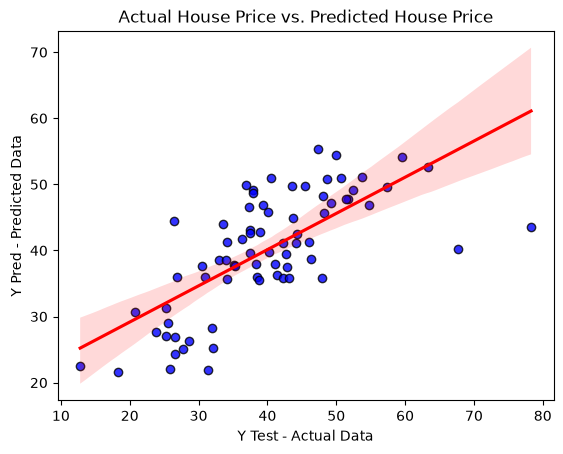

In [509]:
sns.regplot(x = y_test, y = y_pred, scatter_kws={'color': 'blue', 'edgecolor': 'black'}, line_kws = {'color': 'red'})
plt.xlabel('Y Test - Actual Data')
plt.ylabel('Y Pred - Predicted Data')
plt.title('Actual House Price vs. Predicted House Price')
plt.show()

## Using Random Forest

In [510]:
from sklearn.ensemble import RandomForestRegressor

In [511]:
rf_model = RandomForestRegressor()

In [512]:
rf_model.fit(x_train_scale, y_train)
rf_pred = rf_model.predict(x_test_scale)

In [513]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(mse)
rf_r2 = r2_score(y_test, rf_pred)

In [514]:
print(f'Mean Absolute Error: {rf_mae}')
print(f'Mean Squared Error: {rf_mse}')
print(f'Root Mean Squared Error: {rf_rmse}')
print(f'R2 Score: {rf_r2}')

Mean Absolute Error: 5.660883093970589
Mean Squared Error: 59.06837427548719
Root Mean Squared Error: 8.074006486481586
R2 Score: 0.5388399797945058


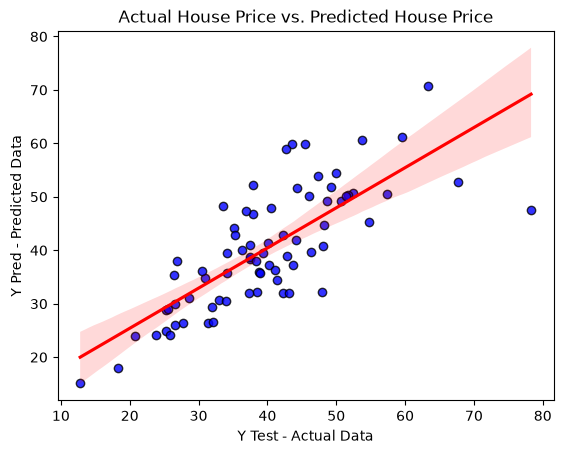

In [515]:
sns.regplot(x = y_test, y = rf_pred, scatter_kws={'color': 'blue', 'edgecolor': 'black'}, line_kws = {'color': 'red'})
plt.xlabel('Y Test - Actual Data')
plt.ylabel('Y Pred - Predicted Data')
plt.title('Actual House Price vs. Predicted House Price')
plt.show()

## New Data Predictionn

In [516]:
data = {
    'X2 house age': [20, 5, 4],
    'X3 distance to the nearest MRT station': [20.456, 201.333, 100.222],
    'X4 number of convenience stores': [3,6,10], 
    'X5 latitude': [24.97433, 24.98746, 24.95456],
    'X6 longitude': [121.54310, 121.54391, 121.53300] 
}

In [517]:
x_data = pd.DataFrame(data)
x_data_scale = scaler.transform(x_data)

In [518]:
x_lr_pred = model.predict(x_data_scale)
x_rf_pred = rf_model.predict(x_data_scale)

In [519]:
x_data['lr_pred'] = x_lr_pred
x_data['x_rf_pred'] = x_rf_pred


In [520]:
x_data

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,lr_pred,x_rf_pred
0,20,20.456,3,24.97433,121.54310,46.526613,45.860500
1,5,201.333,6,24.98746,121.54391,54.375970,57.806228
2,4,100.222,10,24.95456,121.53300,51.460620,52.778540
